<div style="color: balck; text-transform: capitalize; background-color: #1132;padding: 20px 70px; width: auto; height:max_content"> 

<h1 style="color: red; font-weight: 700; text-transform: capitalize;"> Build new model lstm (long short term memory) and train With kernel os dataset</h1>
<p style>

LSTM (Long Short-Term Memory)

An LSTM is a special type of recurrent neural network (RNN) designed to learn patterns from sequence data without forgetting important information. Unlike simple RNNs, which quickly lose memory over long sequences, an LSTM uses three gates—forget gate, input gate, and output gate—to control the flow of information. These gates decide what to keep, what to remove, and what to output at each time step. This makes LSTMs very good at capturing long-term relationships in data such as text, time-series, event logs, and system behavior patterns.

# Key points:
---
* Remembers long-term dependencies

* Uses gates to control memory

* Works well for sequential and time-series data

* Prevents the "vanishing gradient" problem common in RNN


# layes code
---
       
### First LSTM layer with regularization
        LSTM(256, return_sequences=True, 
                dropout=0.3, recurrent_dropout=0.3,
                kernel_regularizer=l2(0.001)),
        BatchNormalization(),

### Second LSTM layer
        LSTM(128, return_sequences=True,
                dropout=0.2, recurrent_dropout=0.2,
                kernel_regularizer=l2(0.001)),
        BatchNormalization(),

### Third LSTM layer
        LSTM(64, return_sequences=False,
                dropout=0.1, recurrent_dropout=0.1),
        BatchNormalization(),

### Dense layers with careful initialization
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.4),
        BatchNormalization(),

        Dense(64, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.3),
        BatchNormalization(),

        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.2),

### Output layer - predict all features for future timesteps
        Dense(output_len * num_features, activation='linear')
<p>

<img src="png\sensors-23-06400-g005.png" style="width:100%; height:350px; background:#fffa; padding:20px" alt="lstm.png">
 </div>   

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib
import os

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Create model directory if not exists
os.makedirs('model_lstm', exist_ok=True)

# Load preprocessed sequences
print("Loading preprocessed sequences...")
X = np.load('npy/X_sequences.npy')
y = np.load('npy/y_sequences.npy')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Load scalers
scaler_va = joblib.load('pkl/scaler_va.pkl')
scaler_pfn = joblib.load('pkl/scaler_pfn.pkl')
scaler_mapping = joblib.load('pkl/scaler_mapping.pkl')
scaler_latency = joblib.load('pkl/scaler_latency.pkl')

config = joblib.load('pkl/sequence_config.pkl')
SEQ_LEN_X = config['SEQ_LEN_X']
SEQ_LEN_Y = config['SEQ_LEN_Y']
NUM_FEATURES = X.shape[2]

print(f"Sequence configuration: Input={SEQ_LEN_X}, Output={SEQ_LEN_Y}, Features={NUM_FEATURES}")

Loading preprocessed sequences...
X shape: (1805, 40, 5)
y shape: (1805, 5, 5)
Sequence configuration: Input=40, Output=5, Features=5


In [3]:
# ---------- Data Analysis ----------
print("\n=== Data Analysis ===")
print("Input data statistics:")
print(f"X - Min: {X.min():.4f}, Max: {X.max():.4f}, Mean: {X.mean():.4f}, Std: {X.std():.4f}")
print(f"y - Min: {y.min():.4f}, Max: {y.max():.4f}, Mean: {y.mean():.4f}, Std: {y.std():.4f}")

# Check for any anomalies in data
if np.isnan(X).any() or np.isnan(y).any():
    print("Warning: NaN values found in data!")
    X = np.nan_to_num(X)
    y = np.nan_to_num(y)

# ---------- Enhanced Data Splitting ----------
# Split by PID to avoid data leakage
pids = np.array([idx[0] for idx in joblib.load('pkl/pid_indices.pkl')])
unique_pids = np.unique(pids)

# Split PIDs for train/val/test
train_pids, temp_pids = train_test_split(unique_pids, test_size=0.3, random_state=42)
val_pids, test_pids = train_test_split(temp_pids, test_size=0.5, random_state=42)

# Create masks based on PIDs
train_mask = np.isin(pids, train_pids)
val_mask = np.isin(pids, val_pids)
test_mask = np.isin(pids, test_pids)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"\nEnhanced Data Split (by PID):")
print(f"Training set: {X_train.shape[0]} sequences ({len(train_pids)} PIDs)")
print(f"Validation set: {X_val.shape[0]} sequences ({len(val_pids)} PIDs)")
print(f"Test set: {X_test.shape[0]} sequences ({len(test_pids)} PIDs)")


=== Data Analysis ===
Input data statistics:
X - Min: 0.0000, Max: 1.0000, Mean: 0.4082, Std: 0.3764
y - Min: 0.0000, Max: 1.0000, Mean: 0.4105, Std: 0.3766

Enhanced Data Split (by PID):
Training set: 1085 sequences (9 PIDs)
Validation set: 362 sequences (2 PIDs)
Test set: 358 sequences (2 PIDs)


In [4]:


# ---------- Improved LSTM Model Architecture ----------
def create_enhanced_lstm_model(seq_len, num_features, output_len):
    """Create enhanced LSTM model with better architecture"""
    model = Sequential([
        Input(shape=(seq_len, num_features)),
        
        # First LSTM layer with regularization
        LSTM(256, return_sequences=True, 
             dropout=0.3, recurrent_dropout=0.3,
             kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        
        # Second LSTM layer
        LSTM(128, return_sequences=True,
             dropout=0.2, recurrent_dropout=0.2,
             kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        
        # Third LSTM layer
        LSTM(64, return_sequences=False,
             dropout=0.1, recurrent_dropout=0.1),
        BatchNormalization(),
        
        # Dense layers with careful initialization
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.4),
        BatchNormalization(),
        
        Dense(64, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.3),
        BatchNormalization(),
        
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.2),
        
        # Output layer - predict all features for future timesteps
        Dense(output_len * num_features, activation='linear')
    ])
    
    return model

# Create and compile model
model = create_enhanced_lstm_model(SEQ_LEN_X, NUM_FEATURES, SEQ_LEN_Y)

# Use a more sophisticated optimizer
optimizer = Adam(
    learning_rate=0.0001,  # Lower learning rate
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# Use Huber loss which is more robust to outliers
model.compile(
    optimizer=optimizer,
    loss='mse',  # Using MSE for stability, we'll add robustness elsewhere
    metrics=['mae']
)

print("\nEnhanced Model Architecture:")
model.summary()

# ---------- Enhanced Callbacks ----------
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=45,  # Increased patience
        restore_best_weights=True,
        verbose=2,
        min_delta=0.0001
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    ),
    
    ModelCheckpoint(
        'model_lstm/best_enhanced_lstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    
    # TensorBoard for visualization (optional)
    tf.keras.callbacks.TensorBoard(log_dir='model_lstm/logs', histogram_freq=1)
]



Enhanced Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 256)        │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 40, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │           825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,857 (2.05 MB)

 Trainable params: 535,577 (2.04 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [5]:
# ---------- Model Training with Gradient Clipping ----------
print("\nStarting enhanced model training...")

# Reshape y for training
y_train_flat = y_train.reshape(y_train.shape[0], -1)
y_val_flat = y_val.reshape(y_val.shape[0], -1)

history = model.fit(
    X_train, y_train_flat,
    batch_size=128,  # Smaller batch size for better convergence
    epochs=50,     # More epochs
    validation_data=(X_val, y_val_flat),
    callbacks=callbacks,
    verbose=2,
    shuffle=True    # Shuffle training data
)

# Save final model
model.save('model_lstm/final_enhanced_lstm_model.keras')
print("Enhanced model training completed!")


Starting enhanced model training...
Epoch 1/50

Epoch 1: val_loss improved from inf to 0.59624, saving model to model_lstm/best_enhanced_lstm_model.keras
9/9 - 20s - 2s/step - loss: 1.9165 - mae: 0.9833 - val_loss: 0.5962 - val_mae: 0.3616 - learning_rate: 1.0000e-04
Epoch 2/50

Epoch 2: val_loss improved from 0.59624 to 0.59132, saving model to model_lstm/best_enhanced_lstm_model.keras
9/9 - 4s - 434ms/step - loss: 1.9027 - mae: 0.9793 - val_loss: 0.5913 - val_mae: 0.3617 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 3: val_loss improved from 0.59132 to 0.58927, saving model to model_lstm/best_enhanced_lstm_model.keras
9/9 - 4s - 438ms/step - loss: 1.8400 - mae: 0.9556 - val_loss: 0.5893 - val_mae: 0.3652 - learning_rate: 1.0000e-04
Epoch 4/50

Epoch 4: val_loss improved from 0.58927 to 0.58914, saving model to model_lstm/best_enhanced_lstm_model.keras
9/9 - 4s - 432ms/step - loss: 1.8161 - mae: 0.9491 - val_loss: 0.5891 - val_mae: 0.3676 - learning_rate: 1.0000e-04
Epoch 5/50

Epoch

In [1]:
# ---------- Advanced Evaluation ----------
def evaluate_model_comprehensively(model, X_test, y_test, scalers):
    """Comprehensive model evaluation"""
    print("\n=== Comprehensive Model Evaluation ===")
    
    # Load best model
    best_model = tf.keras.models.load_model('model_lstm/best_enhanced_lstm_model.keras')
    
    # Predict
    y_pred = best_model.predict(X_test)
    y_pred_reshaped = y_pred.reshape(y_test.shape[0], SEQ_LEN_Y, NUM_FEATURES)
    
    # Calculate metrics
    feature_names = ['VA', 'PFN', 'Folio_Index', 'Mapping', 'Latency']
    
    print("\nPer-Feature Metrics:")
    print("-" * 60)
    for i, feature_name in enumerate(feature_names):
        actual_flat = y_test[:, :, i].flatten()
        pred_flat = y_pred_reshaped[:, :, i].flatten()
        
        mse = mean_squared_error(actual_flat, pred_flat)
        mae = mean_absolute_error(actual_flat, pred_flat)
        rmse = np.sqrt(mse)
        
        # Calculate R² score
        ss_res = np.sum((actual_flat - pred_flat) ** 2)
        ss_tot = np.sum((actual_flat - np.mean(actual_flat)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        print(f"{feature_name:12} - MSE: {mse:.6f}, MAE: {mae:.6f}, RMSE: {rmse:.6f}, R²: {r2:.4f}")
    
    return y_pred_reshaped

# Run comprehensive evaluation
y_pred_enhanced = evaluate_model_comprehensively(model, X_test, y_test, [scaler_va, scaler_pfn, scaler_mapping, scaler_latency])


NameError: name 'model' is not defined

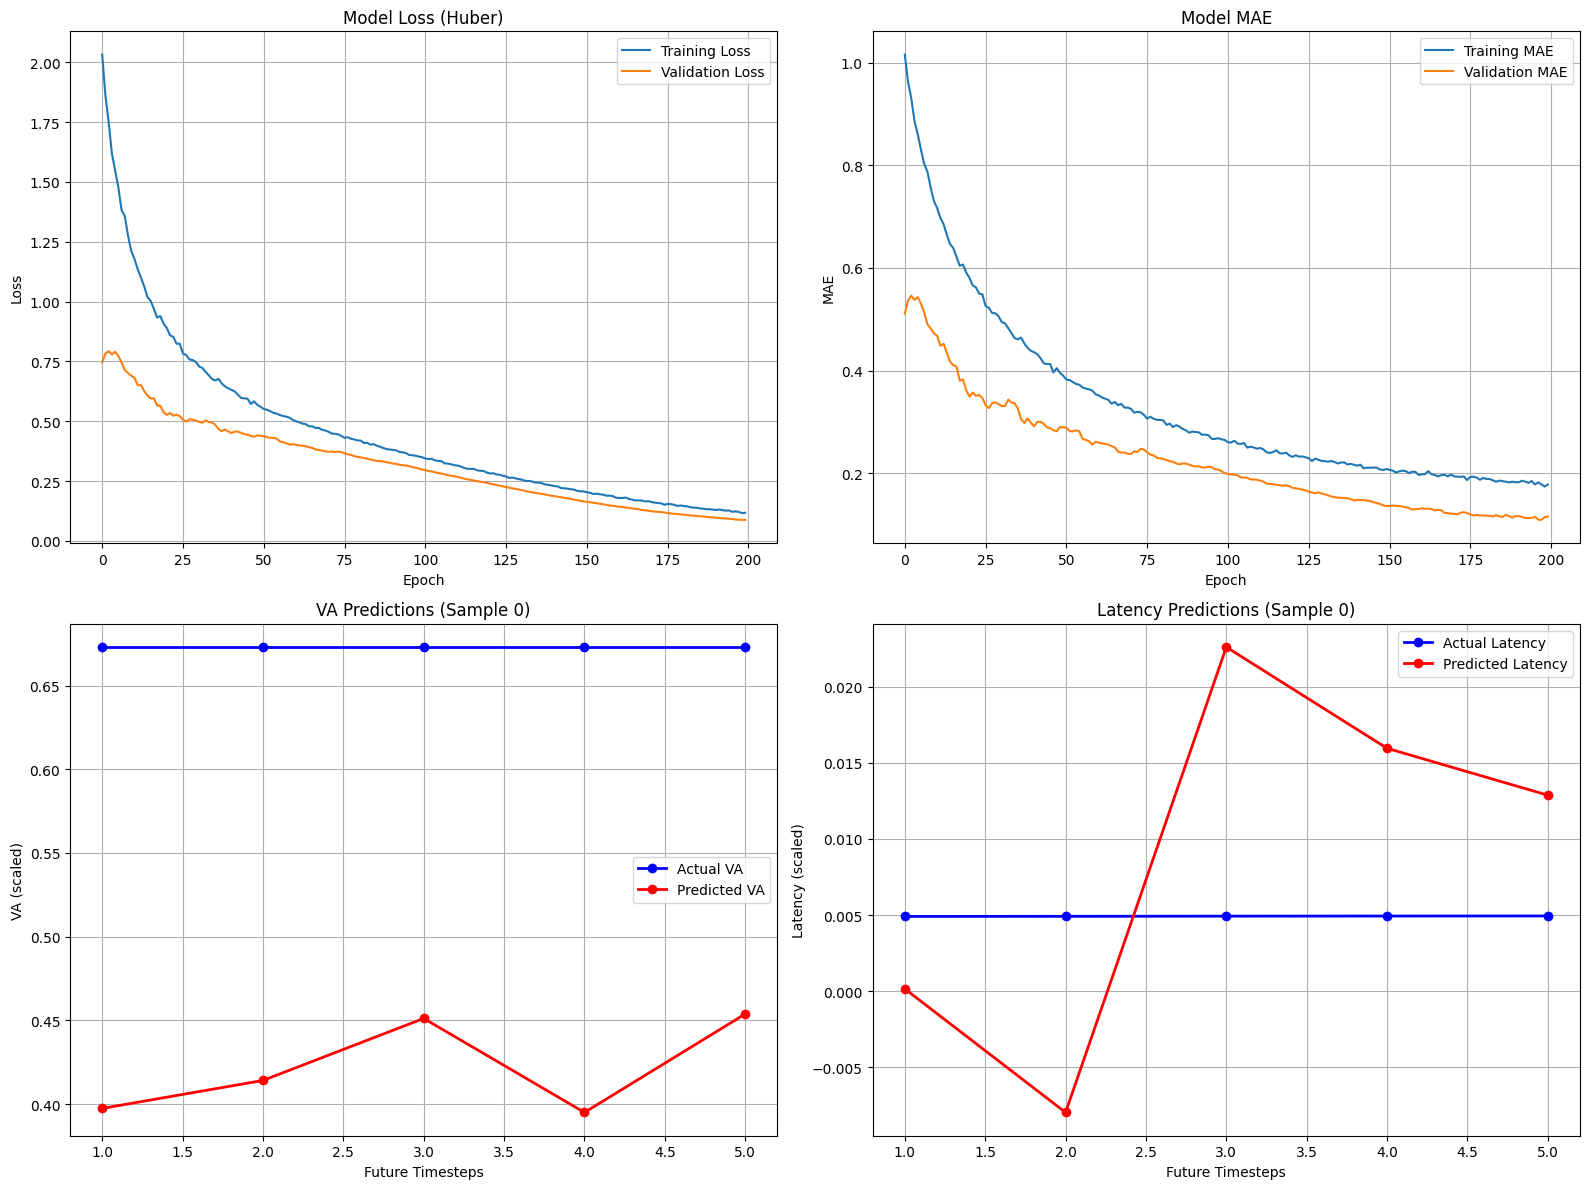

In [7]:
# ---------- Advanced Visualization ----------
def plot_advanced_results(history, y_test, y_pred, sample_idx=0):
    """Plot advanced training results and predictions"""
    
    # Training history
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Loss
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss (Huber)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # MAE
    ax2.plot(history.history['mae'], label='Training MAE')
    ax2.plot(history.history['val_mae'], label='Validation MAE')
    ax2.set_title('Model MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend()
    ax2.grid(True)
    
    # Sample predictions for VA
    timesteps = range(1, SEQ_LEN_Y + 1)
    ax3.plot(timesteps, y_test[sample_idx, :, 0], 'bo-', label='Actual VA', linewidth=2)
    ax3.plot(timesteps, y_pred[sample_idx, :, 0], 'ro-', label='Predicted VA', linewidth=2)
    ax3.set_title(f'VA Predictions (Sample {sample_idx})')
    ax3.set_xlabel('Future Timesteps')
    ax3.set_ylabel('VA (scaled)')
    ax3.legend()
    ax3.grid(True)
    
    # Sample predictions for Latency
    ax4.plot(timesteps, y_test[sample_idx, :, 4], 'bo-', label='Actual Latency', linewidth=2)
    ax4.plot(timesteps, y_pred[sample_idx, :, 4], 'ro-', label='Predicted Latency', linewidth=2)
    ax4.set_title(f'Latency Predictions (Sample {sample_idx})')
    ax4.set_xlabel('Future Timesteps')
    ax4.set_ylabel('Latency (scaled)')
    ax4.legend()
    ax4.grid(True)
    
    plt.tight_layout()
    plt.savefig('png/enhanced_training_results.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_advanced_results(history, y_test, y_pred_enhanced)

In [8]:
# ---------- Feature Importance Analysis ----------
def analyze_feature_importance(model, X_sample, feature_names):
    """Analyze which features are most important for predictions"""
    print("\n=== Feature Importance Analysis ===")
    
    # Use GradientTape to compute gradients (feature importance)
    X_tensor = tf.convert_to_tensor(X_sample, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model(X_tensor)
    
    # Compute gradients of predictions w.r.t input features
    gradients = tape.gradient(predictions, X_tensor)
    
    # Average absolute gradients across samples and timesteps
    feature_importance = tf.reduce_mean(tf.abs(gradients), axis=[0, 1])
    
    print("Feature Importance (higher = more important):")
    for i, feature_name in enumerate(feature_names):
        print(f"{feature_name:12}: {feature_importance[i]:.6f}")
    
    return feature_importance.numpy()

# Analyze feature importance
feature_names = ['VA', 'PFN', 'Folio_Index', 'Mapping', 'Latency']
importance = analyze_feature_importance(model, X_train[:100], feature_names)


=== Feature Importance Analysis ===
Feature Importance (higher = more important):
VA          : 0.043449
PFN         : 0.252931
Folio_Index : 0.094481
Mapping     : 0.158918
Latency     : 0.018206


In [9]:
# ---------- Save Enhanced Results ----------
enhanced_results = {
    'training_history': history.history,
    'feature_importance': dict(zip(feature_names, importance)),
    'data_split_info': {
        'train_pids': len(train_pids),
        'val_pids': len(val_pids),
        'test_pids': len(test_pids)
    },
    'model_config': {
        'input_seq_len': SEQ_LEN_X,
        'output_seq_len': SEQ_LEN_Y,
        'num_features': NUM_FEATURES
    }
}

joblib.dump(enhanced_results, 'model_lstm/enhanced_training_results.pkl')

['model_lstm/enhanced_training_results.pkl']

<div style="color: balck; text-transform: capitalize; background-color: #1132;padding: 20px 70px; width: auto; height:max_content"> 

<h1 style="color: red; font-weight: 700; text-transform: capitalize;">Build new model seq2seq and train With kernel os dataset. it mainly used for next text prediction in input sequence.</h1>
<p style>
# Encoder
x = layers.LSTM(256, return_sequences=True)(inp)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(128)(x)

# Bridge to horizon
x = layers.RepeatVector(seq_len_y)(x)

# Decoder
x = layers.LSTM(512, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(256, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(128, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(64, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(32, return_sequences=True)(x)

out = layers.TimeDistributed(layers.Dense(n_features))(x)
<p>

<img src="png\20181023160903403.png" style="width:auto; hieght:350px; background:#fffa; padding:20px" alt="seq-2-seq.png">
 </div>   

In [7]:
import os
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Load sequences & config
# -----------------------------
os.makedirs("model", exist_ok=True)

X = np.load('npy/X_sequences.npy')        # shape: (N, 10, 5) in scaled space
y = np.load('npy/y_sequences.npy')        # shape: (N, 5, 5)  in scaled space
cfg = joblib.load('pkl/sequence_config.pkl')
SEQ_LEN_X, SEQ_LEN_Y = cfg['SEQ_LEN_X'], cfg['SEQ_LEN_Y']
N_FEATURES = X.shape[-1]  # expect 5

print("X:", X.shape, "y:", y.shape)

# -----------------------------
# Train/Val/Test split
# -----------------------------
N = len(X)
idx = np.arange(N)
np.random.shuffle(idx)

train_end = int(0.8 * N)
val_end   = int(0.9 * N)

tr_idx, va_idx, te_idx = idx[:train_end], idx[train_end:val_end], idx[val_end:]
Xtr, ytr = X[tr_idx], y[tr_idx]
Xva, yva = X[va_idx], y[va_idx]
Xte, yte = X[te_idx], y[te_idx]

print(f"Splits -> train: {Xtr.shape}, val: {Xva.shape}, test: {Xte.shape}")

# -----------------------------
# Weighted loss (emphasize latency column)
# feature order: [va, pfn, folio, mapping, latency]
# -----------------------------
LATENCY_WEIGHT = 3.0
FEATURE_WEIGHTS = tf.constant([1.0, 1.0, 1.0, 1.0, LATENCY_WEIGHT], dtype=tf.float32)

def weighted_mse(y_true, y_pred):
    # y_* shape: (B, T, F)
    diff2 = tf.square(y_true - y_pred)
    return tf.reduce_mean(diff2 * FEATURE_WEIGHTS)

# -----------------------------
# Model: stacked encoder–decoder LSTM
# -----------------------------
def build_model(seq_len_x=SEQ_LEN_X, seq_len_y=SEQ_LEN_Y, n_features=N_FEATURES):
    inp = keras.Input(shape=(seq_len_x, n_features))

    # Encoder
    x = layers.LSTM(256, return_sequences=True)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(128)(x)

    # Bridge to horizon
    x = layers.RepeatVector(seq_len_y)(x)

    # Decoder
    x = layers.LSTM(512, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(256, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32, return_sequences=True)(x)

    out = layers.TimeDistributed(layers.Dense(n_features))(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss=weighted_mse,
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

model = build_model()
model.summary()

# -----------------------------
# Callbacks
# -----------------------------
ckpt_path = "model/seq2seq_lstm.keras"  # Keras v3 format
callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=4, factor=0.5, min_lr=1e-5, verbose=1)
]



X: (1805, 40, 5) y: (1805, 5, 5)
Splits -> train: (1444, 40, 5), val: (180, 40, 5), test: (181, 40, 5)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 40, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 40, 256)        │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 5, 512)         │     1,312,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 5, 256)         │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 5, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 5, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 5, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 5)           │           165 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,824,741 (10.78 MB)

 Trainable params: 2,824,741 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# -----------------------------
# Train
# -----------------------------
history = model.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)



Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - loss: 0.3263 - mae: 0.4116
Epoch 1: val_loss improved from inf to 0.31308, saving model to model/seq2seq_lstm.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 368ms/step - loss: 0.3263 - mae: 0.4115 - val_loss: 0.3131 - val_mae: 0.4063 - learning_rate: 1.0000e-05
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - loss: 0.3254 - mae: 0.4108
Epoch 2: val_loss improved from 0.31308 to 0.31197, saving model to model/seq2seq_lstm.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - loss: 0.3253 - mae: 0.4108 - val_loss: 0.3120 - val_mae: 0.4054 - learning_rate: 1.0000e-05
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.3242 - mae: 0.4098
Epoch 3: val_loss improved from 0.31197 to 0.31043, saving model to model/seq2seq_lstm.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - loss: 0.3241 - mae: 0.4098 - val_loss: 0.3104 - val_mae: 0.4041 - learning_rate: 1.0000e-05
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.3225 - mae: 0.4

In [10]:
# -----------------------------
# Evaluate
# -----------------------------
test_loss, test_mae = model.evaluate(Xte, yte, verbose=0)
print(f"[TEST] Weighted MSE: {test_loss:.6f} | MAE: {test_mae:.6f}")

# Detailed per-feature MAE over the whole horizon
yhat = model.predict(Xte, verbose=0)   # (B, 5, 5)
mae_per_feature = np.mean(np.abs(yhat - yte), axis=(0,1))  # (5,)
print("Per-feature MAE (order=[va,pfn,folio,mapping,latency]):", mae_per_feature)

# -----------------------------
# Save
# -----------------------------
model.save(ckpt_path)
print(f"Saved best model to: {ckpt_path}")

[TEST] Weighted MSE: 0.095359 | MAE: 0.191681
Per-feature MAE (order=[va,pfn,folio,mapping,latency]): [0.24161846 0.29476017 0.07665847 0.28275416 0.06261255]
Saved best model to: model/seq2seq_lstm.keras


In [11]:
# -----------------------------
# Inverse-transform utilities
# -----------------------------

scaler_va       = joblib.load('pkl/scaler_va.pkl')
scaler_pfn      = joblib.load('pkl/scaler_pfn.pkl')
scaler_mapping  = joblib.load('pkl/scaler_mapping.pkl')
scaler_latency  = joblib.load('pkl/scaler_latency.pkl')
folio_scaler    = joblib.load('pkl/scaler_index.pkl')  # << new

def inverse_transform_batch(batch_scaled):
    """
    batch_scaled: (horizon, 5) order [va, pfn, folio, mapping, latency] (scaled)
    returns dict of arrays in original units.
    """
    va_inv       = scaler_va.inverse_transform(batch_scaled[:, [0]]).ravel()
    pfn_inv      = scaler_pfn.inverse_transform(batch_scaled[:, [1]]).ravel()
    folio_inv    = folio_scaler.inverse_transform(batch_scaled[:, [2]]).ravel()
    mapping_inv  = scaler_mapping.inverse_transform(batch_scaled[:, [3]]).ravel()
    latency_inv  = scaler_latency.inverse_transform(batch_scaled[:, [4]]).ravel()
    # folio is integer-like
    folio_inv    = np.rint(folio_inv).astype(int)
    return {
        "VA": va_inv.astype(np.int64),
        "PFN": pfn_inv.astype(np.int64),
        "folio_index": folio_inv,
        "mapping": mapping_inv.astype(np.int64),
        "latency_mcs": latency_inv
    }

if len(Xte) > 0:
    sample_idx = 43
    pred_scaled = yhat[sample_idx]     # (5, 5)
    true_scaled = yte[sample_idx]      # (5, 5)
    
    pred_orig = inverse_transform_batch(pred_scaled)
    true_orig = inverse_transform_batch(true_scaled)

    print("\n=== Inverse-transform check (one test sample) ===")

    for t in range(SEQ_LEN_Y):
        print(
            f"t+{t}: "
            f"VA_pred={int(pred_orig['VA'][t])} | VA_true={int(true_orig['VA'][t])} ; "
            f"PFN_pred={int(pred_orig['PFN'][t])} | PFN_true={int(true_orig['PFN'][t])} ; "
            f"folio_pred={pred_orig['folio_index'][t]} | folio_true={true_orig['folio_index'][t]} ; "
            f"mapping_pred={int(pred_orig['mapping'][t])} | mapping_true={int(true_orig['mapping'][t])} ; "
            f"lat_us_pred={pred_orig['latency_mcs'][t]/1000:.3f} | lat_us_true={true_orig['latency_mcs'][t]/1000:.3f}"
        )


=== Inverse-transform check (one test sample) ===
t+0: VA_pred=104897403944960 | VA_true=123325597974528 ; PFN_pred=330840 | PFN_true=589948 ; folio_pred=15 | folio_true=1 ; mapping_pred=803970816 | mapping_true=754959950 ; lat_us_pred=2589.961 | lat_us_true=1.931
t+1: VA_pred=118565986369536 | VA_true=123325597978624 ; PFN_pred=719469 | PFN_true=431803 ; folio_pred=25 | folio_true=2 ; mapping_pred=1671701376 | mapping_true=754959950 ; lat_us_pred=4016.186 | lat_us_true=1.932
t+2: VA_pred=125388701302784 | VA_true=123325597982720 ; PFN_pred=923234 | PFN_true=597979 ; folio_pred=31 | folio_true=3 ; mapping_pred=2141577856 | mapping_true=754959950 ; lat_us_pred=5185.287 | lat_us_true=1.933
t+3: VA_pred=128298558423040 | VA_true=123325597986816 ; PFN_pred=1006196 | PFN_true=379578 ; folio_pred=33 | folio_true=4 ; mapping_pred=2341110528 | mapping_true=754959950 ; lat_us_pred=5653.983 | lat_us_true=1.934
t+4: VA_pred=129733471764480 | VA_true=123325597990912 ; PFN_pred=1035559 | PFN_true=